In [50]:
import numpy as np
import pandas as pd
import warnings
import yfinance as yf
from matplotlib import pyplot as plt
warnings.simplefilter(action='ignore', category=FutureWarning)
from datetime import datetime
from datetime import timedelta

In [10]:
dt = datetime(2024, 1, 1, 12, 30, 45)
print("Datetime object: ", dt)

Datetime object:  2024-01-01 12:30:45


In [12]:
print("Year:", dt.year)
print("Month:", dt.month)
print("Day:", dt.day)
print("Hour:", dt.hour)
print("Minute:", dt.minute)
print("Second:", dt.second)

Year: 2024
Month: 1
Day: 1
Hour: 12
Minute: 30
Second: 45


In [13]:
current_dt = datetime.now()
print("Current datetime:", current_dt)

Current datetime: 2026-06-08 09:43:51.876189


In [14]:
# Add 5 days to the current date and time
future_date = current_dt + timedelta(days=5)
print("Future date:", future_date)

# Subtract 2 hours
past_time = current_dt - timedelta(hours=2)
print("Past time:", past_time)

Future date: 2026-06-13 09:43:51.876189
Past time: 2026-06-08 07:43:51.876189


In [15]:
# Format a datetime object into a string
formatted_date = dt.strftime("%Y-%m-%d %H:%M:%S")
print("Formatted date:", formatted_date)

# Parse a string into a datetime object
date_string = "2024-01-01 12:30:45"
parsed_date = datetime.strptime(date_string, "%Y-%m-%d %H:%M:%S")
print("Parsed datetime:", parsed_date)

Formatted date: 2024-01-01 12:30:45
Parsed datetime: 2024-01-01 12:30:45


In [16]:
dates = pd.to_datetime([datetime(2024, 7, 4),
                        '4th of July, 2024',
                        '2024-Jul-4',
                        '20240704',
                        '2024/07/04'])
print(type(dates))
dates

<class 'pandas.DatetimeIndex'>


DatetimeIndex(['2024-07-04', '2024-07-04', '2024-07-04', '2024-07-04',
               '2024-07-04'],
              dtype='datetime64[us]', freq=None)

In [17]:
# Create dates to use for time series index
datestrs = ["2024-01-02 12:00:00", "2024-02-02 00:00:00",
            "2024-03-02 12:00:00", "2024-04-02 00:00:00",
            "2024-05-02 12:00:00", "2024-06-02 00:00:00",
            "2024-07-02 12:00:00", "2024-08-02 00:00:00"]

# Parse strings into dates using pandas.to_datetime
dates = pd.to_datetime(datestrs)
print(type(dates))

# Create a pandas Series using the dates as index
# and random numbers from standard normal distribution as values
ts = pd.Series(np.random.standard_normal(8), index=dates)
ts

<class 'pandas.DatetimeIndex'>


2024-01-02 12:00:00    2.489366
2024-02-02 00:00:00   -0.610329
2024-03-02 12:00:00    0.432802
2024-04-02 00:00:00    1.092968
2024-05-02 12:00:00    0.586180
2024-06-02 00:00:00   -0.645068
2024-07-02 12:00:00    1.605965
2024-08-02 00:00:00    0.207972
dtype: float64

In [18]:
ts.index

DatetimeIndex(['2024-01-02 12:00:00', '2024-02-02 00:00:00',
               '2024-03-02 12:00:00', '2024-04-02 00:00:00',
               '2024-05-02 12:00:00', '2024-06-02 00:00:00',
               '2024-07-02 12:00:00', '2024-08-02 00:00:00'],
              dtype='datetime64[us]', freq=None)

In [21]:
# use datetime to specify start date
startDate = datetime(2023, 1, 2)

# use datetime to specify end date
endDate = datetime(2024, 1, 30)

# specify which stock using Ticker() then pass the stock symbol for Meta
stock = yf.download("META", start=startDate, end=endDate)
stock

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-01-03,123.768723,125.386036,121.327878,121.863674,35528500
2023-01-04,126.378258,128.045177,124.870089,126.388174,32397100
2023-01-05,125.951607,127.519306,123.570292,125.147909,25447100
2023-01-06,129.007629,129.315213,125.058616,127.965802,27584500
2023-01-09,128.461914,131.914814,128.273391,130.138758,26649100
...,...,...,...,...,...
2024-01-23,382.200684,385.355916,379.104952,381.625183,15506100
2024-01-24,387.657867,393.065413,384.790356,386.963306,15698500


In [22]:
stock.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 269 entries, 2023-01-03 to 2024-01-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, META)   269 non-null    float64
 1   (High, META)    269 non-null    float64
 2   (Low, META)     269 non-null    float64
 3   (Open, META)    269 non-null    float64
 4   (Volume, META)  269 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 12.6 KB


In [23]:
stock.index

DatetimeIndex(['2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06',
               '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
               '2023-01-13', '2023-01-17',
               ...
               '2024-01-16', '2024-01-17', '2024-01-18', '2024-01-19',
               '2024-01-22', '2024-01-23', '2024-01-24', '2024-01-25',
               '2024-01-26', '2024-01-29'],
              dtype='datetime64[s]', name='Date', length=269, freq=None)

In [24]:
stock.index = pd.to_datetime(stock.index)

In [25]:
stock.loc['2024']

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2024-01-02,343.593628,350.410130,337.362528,348.584461,19042200
2024-01-03,341.787842,345.240756,340.507878,342.293880,15451100
2024-01-04,344.417175,345.439154,340.726140,341.817581,12099900
2024-01-05,349.209625,350.747544,343.563927,344.288223,13920700
2024-01-08,355.867310,356.184825,349.308762,351.938152,13890200
2024-01-09,354.646912,357.831939,352.593022,353.624933,13463900
2024-01-10,367.585388,370.036157,356.284060,357.365600,22117200
2024-01-11,366.791595,369.877365,360.104056,369.232432,17205400


In [26]:
stock.index.is_unique

True

In [28]:
# Generate end-of-month business dates
end_of_month_dates = pd.date_range(start=stock.index.min(), end=stock.index.max(), freq='BME')

# Filter DataFrame to get only the rows corresponding to the end-of-month business dates
end_of_month_df = stock[stock.index.isin(end_of_month_dates)]
end_of_month_df

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-01-31,147.810074,148.712992,146.371367,146.798012,29842100
2023-02-28,173.577866,176.167544,170.531762,170.561528,46051100
2023-03-31,210.289764,210.517969,205.160022,205.626363,25440300
2023-04-28,238.448792,238.557920,233.914368,237.148979,39554000
2023-05-31,262.658752,262.936571,256.437585,257.975504,25473700
2023-06-30,284.745483,286.799343,282.205419,282.542768,19694900
2023-07-31,316.119263,323.124288,315.117117,321.169626,25799600
2023-08-31,293.586029,298.755452,293.357809,293.496703,17229900


In [29]:
# move 2 steps forward
stock.shift(2)

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-01-03,NaN,NaN,NaN,NaN,NaN
2023-01-04,NaN,NaN,NaN,NaN,NaN
2023-01-05,123.768723,125.386036,121.327878,121.863674,35528500.0
2023-01-06,126.378258,128.045177,124.870089,126.388174,32397100.0
2023-01-09,125.951607,127.519306,123.570292,125.147909,25447100.0
...,...,...,...,...,...
2024-01-23,380.464386,381.367274,375.027044,376.049023,21670800.0
2024-01-24,378.807281,387.310559,378.192114,384.929252,17680500.0


In [30]:
# move 2 steps backward
stock.shift(-2)

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-01-03,125.951607,127.519306,123.570292,125.147909,25447100.0
2023-01-04,129.007629,129.315213,125.058616,127.965802,27584500.0
2023-01-05,128.461914,131.914814,128.273391,130.138758,26649100.0
2023-01-06,131.954498,132.400991,126.159967,126.279027,28684400.0
2023-01-09,131.855286,132.807818,129.325138,129.940320,25423000.0
...,...,...,...,...,...
2024-01-23,390.118591,392.410603,382.657155,387.132049,15091100.0
2024-01-24,391.071136,393.700497,388.540973,391.279493,13163700.0


In [31]:
# move 2 steps backward, and with daily frequency
stock.shift(-2, freq="D")

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-01-01,123.768723,125.386036,121.327878,121.863674,35528500
2023-01-02,126.378258,128.045177,124.870089,126.388174,32397100
2023-01-03,125.951607,127.519306,123.570292,125.147909,25447100
2023-01-04,129.007629,129.315213,125.058616,127.965802,27584500
2023-01-07,128.461914,131.914814,128.273391,130.138758,26649100
...,...,...,...,...,...
2024-01-21,382.200684,385.355916,379.104952,381.625183,15506100
2024-01-22,387.657867,393.065413,384.790356,386.963306,15698500


In [33]:
# Forward fill the missing values
stock_shifted = stock.shift(-2).ffill()
stock_shifted

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-01-03,125.951607,127.519306,123.570292,125.147909,25447100.0
2023-01-04,129.007629,129.315213,125.058616,127.965802,27584500.0
2023-01-05,128.461914,131.914814,128.273391,130.138758,26649100.0
2023-01-06,131.954498,132.400991,126.159967,126.279027,28684400.0
2023-01-09,131.855286,132.807818,129.325138,129.940320,25423000.0
...,...,...,...,...,...
2024-01-23,390.118591,392.410603,382.657155,387.132049,15091100.0
2024-01-24,391.071136,393.700497,388.540973,391.279493,13163700.0


In [34]:
# Resample data into weekly (every Friday) and get the mean
stock.resample('W-FRI').mean()

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-01-06,126.276554,127.566433,123.706719,125.341390,30239300.0
2023-01-13,132.766129,134.010362,129.656527,130.535633,26787600.0
2023-01-20,134.916248,136.774170,132.410911,134.040620,24669225.0
2023-01-27,144.257938,145.385088,141.096743,141.854793,27463260.0
2023-02-03,163.606107,168.380641,159.663050,161.183122,68165720.0
2023-02-10,181.213925,186.704838,179.285068,183.478163,39251200.0
2023-02-17,174.905432,176.560444,172.351475,173.591742,26161100.0
2023-02-24,170.072857,172.481457,168.331528,170.169601,24208725.0


In [36]:
# Monthly resample and get average, then label with right bin
stock.resample("BME", closed="right").mean()

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-01-31,136.180827,137.649798,133.520701,134.726240,2.743853e+07
2023-02-28,175.104817,178.812565,172.416966,174.631691,4.064057e+07
2023-03-31,192.433789,195.017860,189.068892,191.616724,3.000230e+07
2023-04-28,215.510894,217.449365,212.912339,214.998596,2.350989e+07
2023-05-31,241.467362,244.122433,238.073992,240.269939,2.214227e+07
2023-06-30,274.905066,278.466169,270.858726,273.680867,2.291193e+07
2023-07-31,300.780635,305.656869,296.567197,301.950457,3.125700e+07
2023-08-31,297.523017,301.867619,293.651656,298.075205,1.845678e+07


In [38]:
# Monthly resample and get average, then label with right bin
stock.resample("ME", closed="right", label='right').mean()

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-01-31,136.180827,137.649798,133.520701,134.726240,2.743853e+07
2023-02-28,175.104817,178.812565,172.416966,174.631691,4.064057e+07
2023-03-31,192.433789,195.017860,189.068892,191.616724,3.000230e+07
2023-04-30,215.510894,217.449365,212.912339,214.998596,2.350989e+07
2023-05-31,241.467362,244.122433,238.073992,240.269939,2.214227e+07
2023-06-30,274.905066,278.466169,270.858726,273.680867,2.291193e+07
2023-07-31,300.780635,305.656869,296.567197,301.950457,3.125700e+07
2023-08-31,297.523017,301.867619,293.651656,298.075205,1.845678e+07


In [39]:
stock.resample("ME", closed="left", label='left').mean()

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2022-12-31,135.568761,137.067524,132.844350,134.090884,2.731203e+07
2023-01-31,173.748618,177.367588,171.145366,173.380980,3.978747e+07
2023-02-28,190.837620,193.524363,187.563315,190.092166,3.089843e+07
2023-03-31,215.249837,217.102795,212.524723,214.529985,2.360641e+07
2023-04-30,240.458248,243.226522,237.199535,239.426816,2.198363e+07
2023-05-31,273.853317,277.329846,269.631686,272.510997,2.318711e+07
2023-06-30,299.211946,303.840622,294.921612,300.019114,3.095176e+07
2023-07-31,298.502723,302.927134,294.597713,299.278375,1.882937e+07


Label comparison: Changing label='right' to label='left' only shifts the date index by one period the actual computed values remain identical since the same data points are being averaged.

closed + sum: When switching closed settings, .mean() shows negligible difference since one extra/fewer boundary day barely affects the average. With .sum() however, the difference becomes visible one bin gains a day's values while the adjacent bin loses them, causing totals to differ between settings.

In [44]:
# Annual Period resampling
annual_stock = stock.resample("YE-DEC").mean()
annual_stock

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-12-31,259.388732,262.706734,255.751317,258.847738,2.423055e+07
2024-12-31,368.789098,371.850859,363.879726,367.321143,1.623367e+07


In [45]:
# Upsample and fill forward each 4-hour value
upsample_4H = stock.resample('4h').ffill()
upsample_4H.head(20)

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-01-03 00:00:00,123.768723,125.386036,121.327878,121.863674,35528500
2023-01-03 04:00:00,123.768723,125.386036,121.327878,121.863674,35528500
2023-01-03 08:00:00,123.768723,125.386036,121.327878,121.863674,35528500
2023-01-03 12:00:00,123.768723,125.386036,121.327878,121.863674,35528500
2023-01-03 16:00:00,123.768723,125.386036,121.327878,121.863674,35528500
2023-01-03 20:00:00,123.768723,125.386036,121.327878,121.863674,35528500
2023-01-04 00:00:00,126.378258,128.045177,124.870089,126.388174,32397100
2023-01-04 04:00:00,126.378258,128.045177,124.870089,126.388174,32397100


In [46]:
# Using the rolling operator, compute the 10 day moving average
sma_10 = stock.rolling(10).mean()
sma_10.head(20)

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-01-03,NaN,NaN,NaN,NaN,NaN
2023-01-04,NaN,NaN,NaN,NaN,NaN
2023-01-05,NaN,NaN,NaN,NaN,NaN
2023-01-06,NaN,NaN,NaN,NaN,NaN
2023-01-09,NaN,NaN,NaN,NaN,NaN
2023-01-10,NaN,NaN,NaN,NaN,NaN
2023-01-11,NaN,NaN,NaN,NaN,NaN
2023-01-12,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Date'>

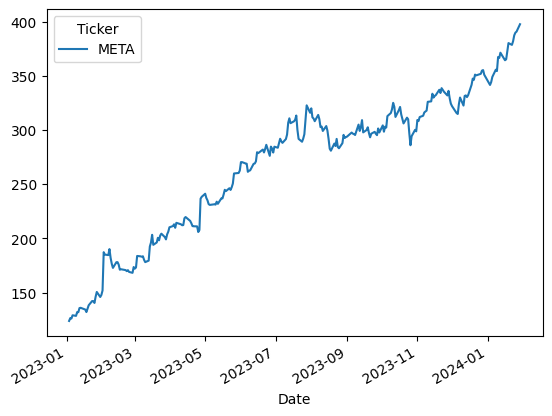

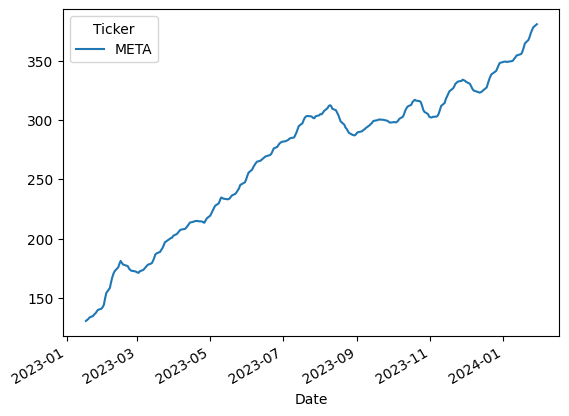

In [51]:
stock['Close'].plot()
sma_10['Close'].plot()

In [52]:
change_std = stock.pct_change().rolling(10, min_periods=3).std()
change_std

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-01-03,NaN,NaN,NaN,NaN,NaN
2023-01-04,NaN,NaN,NaN,NaN,NaN
2023-01-05,NaN,NaN,NaN,NaN,NaN
2023-01-06,0.015124,0.013054,0.019861,0.024021,0.149843
2023-01-09,0.015345,0.011712,0.017958,0.019614,0.123889
...,...,...,...,...,...
2024-01-23,0.015875,0.015697,0.015494,0.015994,0.291829
2024-01-24,0.015532,0.016077,0.015638,0.016038,0.290921


<Axes: xlabel='Date'>

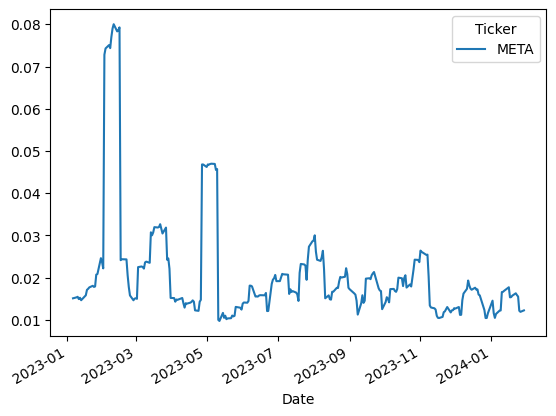

In [53]:
change_std['Close'].plot()

In [54]:
expanding_mean = change_std.expanding().mean()
expanding_mean

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-01-03,NaN,NaN,NaN,NaN,NaN
2023-01-04,NaN,NaN,NaN,NaN,NaN
2023-01-05,NaN,NaN,NaN,NaN,NaN
2023-01-06,0.015124,0.013054,0.019861,0.024021,0.149843
2023-01-09,0.015234,0.012383,0.018910,0.021818,0.136866
...,...,...,...,...,...
2024-01-23,0.021080,0.019613,0.019352,0.022225,0.388043
2024-01-24,0.021059,0.019600,0.019338,0.022201,0.387674


<Axes: xlabel='Date'>

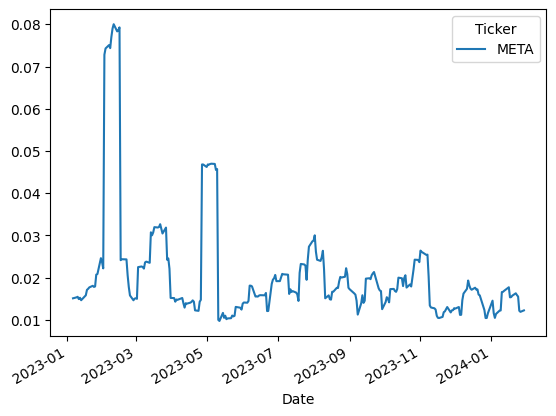

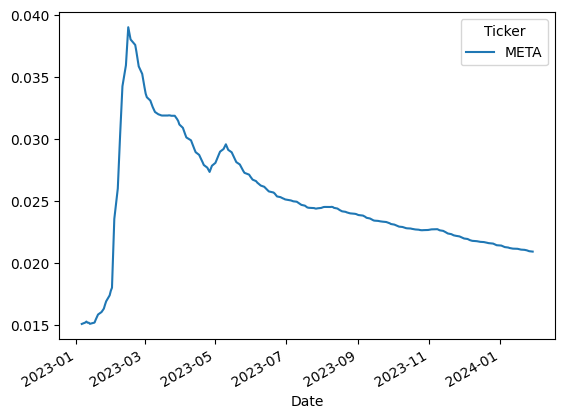

In [55]:
change_std['Close'].plot()
expanding_mean['Close'].plot()

In [56]:
# exponentially weighted moving average with span and window size of 10.
ewm_10 = stock.ewm(span=10).mean()
ewm_10

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2023-01-03,123.768723,125.386036,121.327878,121.863674,3.552850e+07
2023-01-04,125.203967,126.848563,123.276094,124.352149,3.380623e+07
2023-01-05,125.504513,127.118198,123.394360,124.672039,3.044592e+07
2023-01-06,126.658634,127.842016,123.942658,125.757187,2.950321e+07
2023-01-09,127.176307,129.011206,125.185894,127.015017,2.868387e+07
...,...,...,...,...,...
2024-01-23,370.852022,374.231337,366.623021,370.208733,1.676210e+07
2024-01-24,373.907630,377.655714,369.926173,373.255019,1.656872e+07


<Figure size 1000x700 with 0 Axes>

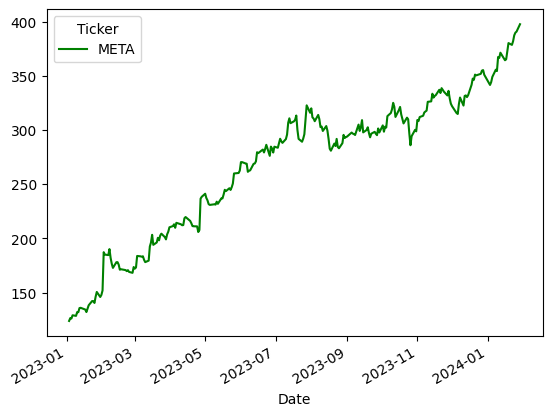

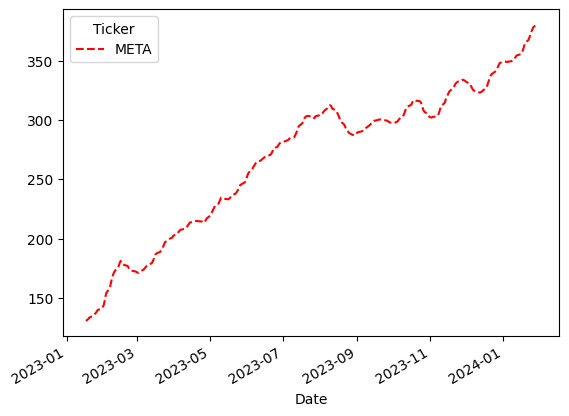

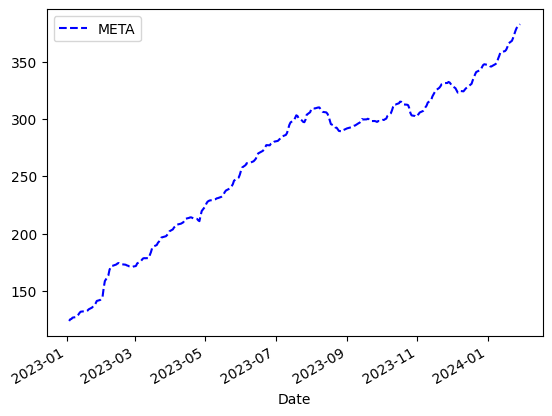

In [57]:
plt.figure(figsize=(10, 7))
stock['Close'].plot(style="g-", label="Price")
sma_10['Close'].plot(style="r--", label="Simple Moving Avg")
ewm_10['Close'].plot(style="b--", label="EW Moving Avg")
plt.legend()